# HR Data Project – Compensation & Data Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Data Loading & Overview

In [2]:
df = pd.read_csv("hr_dataset.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(df.dtypes)
print()
display(df.head(10))

Shape: 301 rows × 7 columns

employee_id         int64
department            str
grade                 str
salary              int64
gender                str
years_experience    int64
absences            int64
dtype: object



,employee_id,department,grade,salary,gender,years_experience,absences
0,1,Finance,G1,50683,M,0,15
1,2,Marketing,G1,40225,M,6,5
2,3,Tech,G3,82159,F,0,7
3,4,Finance,G2,59508,M,12,17
4,5,Finance,G2,19622,M,13,11
5,6,Marketing,G1,150000,M,6,14
6,7,Tech,G4,40073,M,2,8
7,8,Tech,G2,62786,F,10,12
8,9,Finance,G4,38112,F,7,14
9,10,HR,G2,48278,F,2,9


In [3]:
df.describe()

,employee_id,salary,years_experience,absences
count,301.00,301.00,301.00,301.00
mean,150.00,"49,987.37",6.43,9.59
std,87.03,"16,001.11",4.33,5.61
min,1.00,"1,380.00",0.00,0.00
25%,75.00,"38,772.00",2.00,5.00
50%,150.00,"49,722.00",6.00,10.00
75%,225.00,"59,578.00",10.00,14.00
max,300.00,"150,000.00",14.00,19.00


## 2. Data Quality

### 2.1 Missing values & duplicates

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
display(quality_report)

duplicates = df.duplicated().sum()
duplicate_ids = df.duplicated(subset="employee_id").sum()
print(f"\nFull duplicate rows    : {duplicates}")
print(f"Duplicate employee_ids : {duplicate_ids}")

,missing_count,missing_%
employee_id,0,0.00
department,0,0.00
grade,0,0.00
salary,0,0.00
gender,0,0.00
years_experience,0,0.00
absences,0,0.00



Full duplicate rows    : 1
Duplicate employee_ids : 1


### 2.2 Outlier detection – Salary (IQR method)

IQR bounds: [7,563 — 90,787]
Salary outliers detected: 3



,employee_id,department,grade,salary,gender,years_experience,absences
5,6,Marketing,G1,150000,M,6,14
246,247,Tech,G1,96183,M,12,14
30,31,Tech,G1,1380,M,13,13


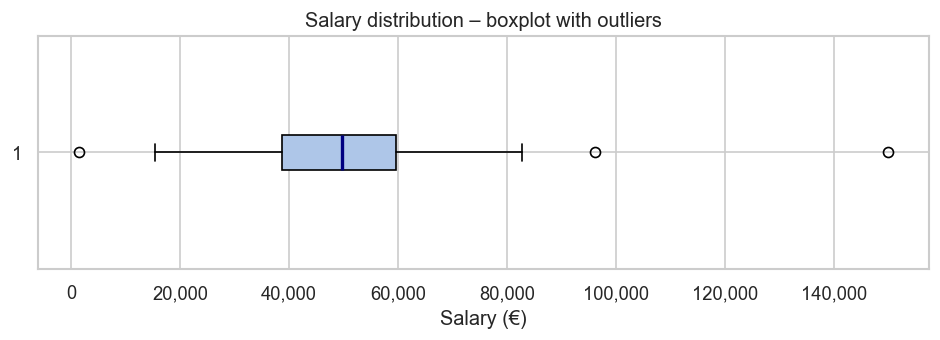

In [5]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["salary"] < lower) | (df["salary"] > upper)].copy()
print(f"IQR bounds: [{lower:,.0f} — {upper:,.0f}]")
print(f"Salary outliers detected: {len(outliers)}\n")
display(outliers.sort_values("salary", ascending=False))

# Boxplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(df["salary"], vert=False, patch_artist=True,
           boxprops=dict(facecolor="#AEC6E8"), medianprops=dict(color="navy", linewidth=2))
ax.set_xlabel("Salary (€)")
ax.set_title("Salary distribution – boxplot with outliers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 2.3 Business-rule inconsistencies

Rules checked:
- Salary must be > 0
- `years_experience` must be ≥ 0
- `absences` must be ≥ 0
- Grade should be one of G1–G5
- Salary floor per grade: G1 ≥ 25 000 €, G2 ≥ 35 000 €, G3 ≥ 45 000 €, G4 ≥ 55 000 €, G5 ≥ 70 000 €

In [6]:
GRADE_FLOOR = {"G1": 25_000, "G2": 35_000, "G3": 45_000, "G4": 55_000, "G5": 70_000}

issues = {}
issues["salary <= 0"]         = df[df["salary"] <= 0]
issues["experience < 0"]      = df[df["years_experience"] < 0]
issues["absences < 0"]        = df[df["absences"] < 0]
issues["unknown grade"]       = df[~df["grade"].isin(GRADE_FLOOR)]

# Salary below grade floor
df["grade_floor"] = df["grade"].map(GRADE_FLOOR)
issues["salary below grade floor"] = df[df["salary"] < df["grade_floor"]]
df.drop(columns="grade_floor", inplace=True)

for label, subset in issues.items():
    flag = "⚠️ " if len(subset) > 0 else "✅ "
    print(f"{flag} {label}: {len(subset)} row(s)")
    if len(subset) > 0:
        display(subset.head(10))

✅  salary <= 0: 0 row(s)
✅  experience < 0: 0 row(s)
✅  absences < 0: 0 row(s)
✅  unknown grade: 0 row(s)
⚠️  salary below grade floor: 110 row(s)


,employee_id,department,grade,salary,gender,years_experience,absences,grade_floor
4,5,Finance,G2,19622,M,13,11,35000
6,7,Tech,G4,40073,M,2,8,55000
8,9,Finance,G4,38112,F,7,14,55000
10,11,Finance,G4,20000,F,13,15,55000
12,13,Finance,G4,31995,M,12,16,55000
13,14,Finance,G3,44982,F,0,6,45000
14,15,Marketing,G3,42875,F,12,13,45000
15,16,Tech,G5,40200,F,12,14,70000
18,19,Marketing,G3,31086,F,2,18,45000
22,23,HR,G4,27209,M,2,17,55000


## 3. Compensation Analysis

### 3.1 Salary distribution

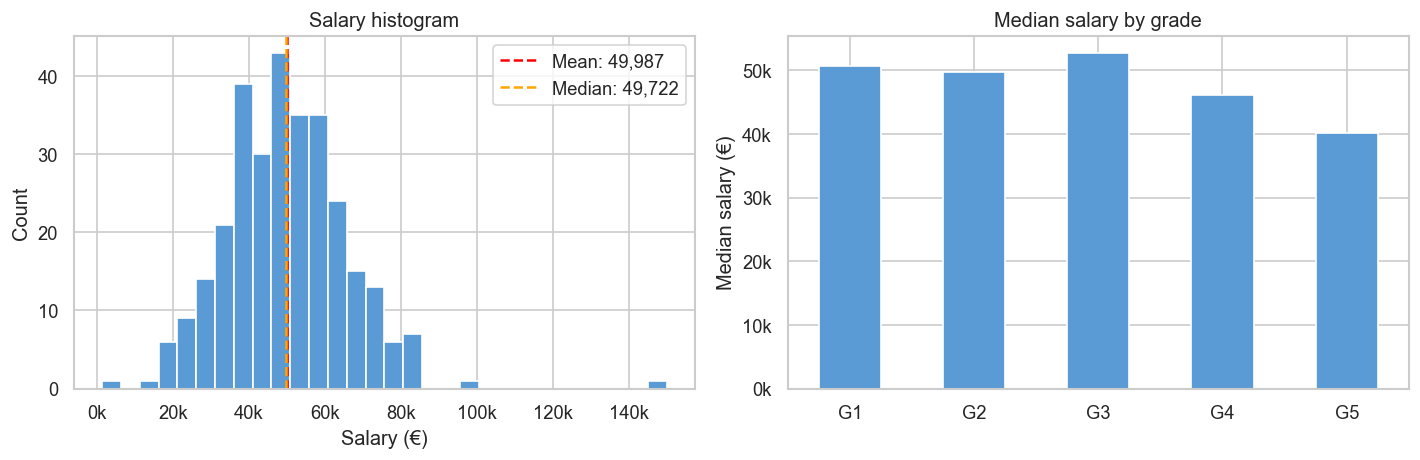

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df["salary"], bins=30, color="#5A9BD5", edgecolor="white")
axes[0].axvline(df["salary"].mean(), color="red", linestyle="--", label=f"Mean: {df['salary'].mean():,.0f}")
axes[0].axvline(df["salary"].median(), color="orange", linestyle="--", label=f"Median: {df['salary'].median():,.0f}")
axes[0].set_title("Salary histogram")
axes[0].set_xlabel("Salary (€)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].legend()

# By grade
grade_order = ["G1", "G2", "G3", "G4", "G5"]
salary_by_grade = df.groupby("grade")["salary"].median().reindex(grade_order)
salary_by_grade.plot(kind="bar", ax=axes[1], color="#5A9BD5", edgecolor="white")
axes[1].set_title("Median salary by grade")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median salary (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Salary by department

,Mean,Median,Std Dev,Headcount
department,,,,
Finance,"50,459.00","50,683.00","16,189.00",78
Tech,"50,191.00","50,358.00","15,714.00",74
Marketing,"50,828.00","49,107.00","17,794.00",81
HR,"48,224.00","48,336.00","13,922.00",68


/var/folders/8b/p3gm7slj2kl6zld02zj8vy480000gn/T/ipykernel_3363/3143353774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="department", y="salary", order=dept_order, ax=ax, palette="Blues")


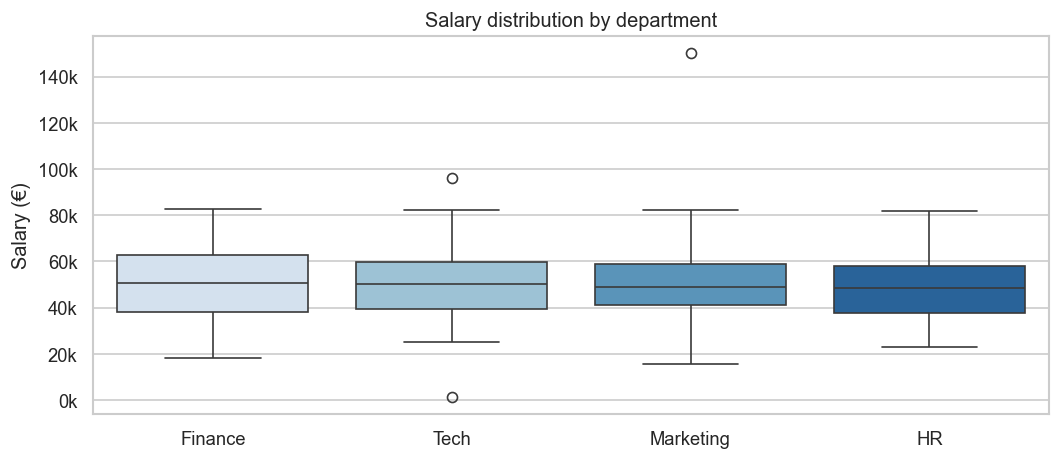

In [8]:
dept_stats = df.groupby("department")["salary"].agg(["mean", "median", "std", "count"]).round(0)
dept_stats.columns = ["Mean", "Median", "Std Dev", "Headcount"]
dept_stats = dept_stats.sort_values("Median", ascending=False)
display(dept_stats)

fig, ax = plt.subplots(figsize=(9, 4))
dept_order = dept_stats.index.tolist()
sns.boxplot(data=df, x="department", y="salary", order=dept_order, ax=ax, palette="Blues")
ax.set_title("Salary distribution by department")
ax.set_xlabel("")
ax.set_ylabel("Salary (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

### 3.3 Salary vs. experience

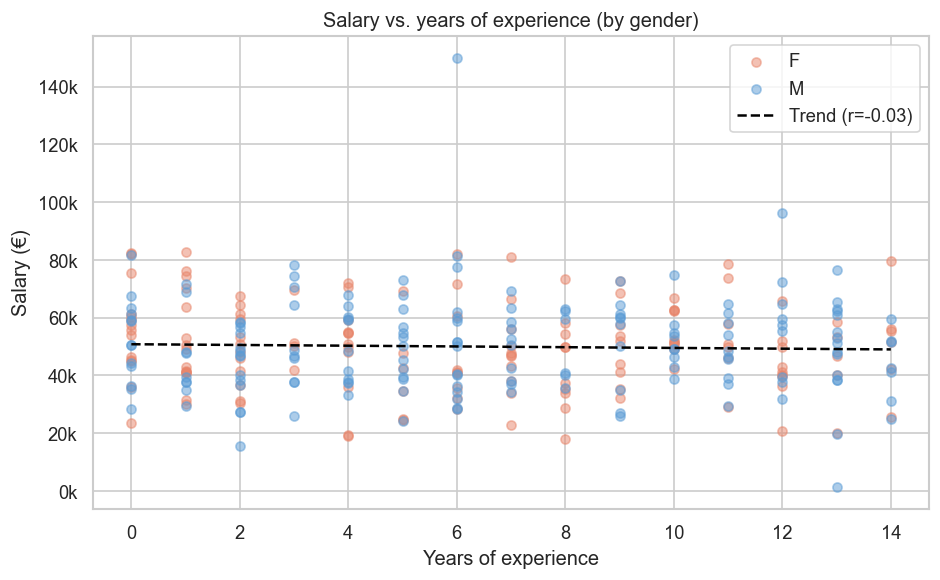

Pearson correlation (experience vs salary): -0.035


In [9]:
corr = df["years_experience"].corr(df["salary"])

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"M": "#5A9BD5", "F": "#E8856A"}
for gender, grp in df.groupby("gender"):
    ax.scatter(grp["years_experience"], grp["salary"], alpha=0.5, s=30,
               color=colors[gender], label=gender)

# Regression line
m, b = np.polyfit(df["years_experience"], df["salary"], 1)
x_line = np.linspace(df["years_experience"].min(), df["years_experience"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--", label=f"Trend (r={corr:.2f})")

ax.set_xlabel("Years of experience")
ax.set_ylabel("Salary (€)")
ax.set_title("Salary vs. years of experience (by gender)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation (experience vs salary): {corr:.3f}")

## 4. Gender Pay Gap Analysis

### 4.1 Global pay gap

,Mean,Median,Headcount
gender,,,
F,"49,864.01","49,816.00",139
M,"50,093.22","49,377.50",162


/var/folders/8b/p3gm7slj2kl6zld02zj8vy480000gn/T/ipykernel_3363/4145041829.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="gender", y="salary", palette={"M": "#5A9BD5", "F": "#E8856A"},



Gender pay gap (mean): 0.5%  (M earns 0.5% more than F on average)


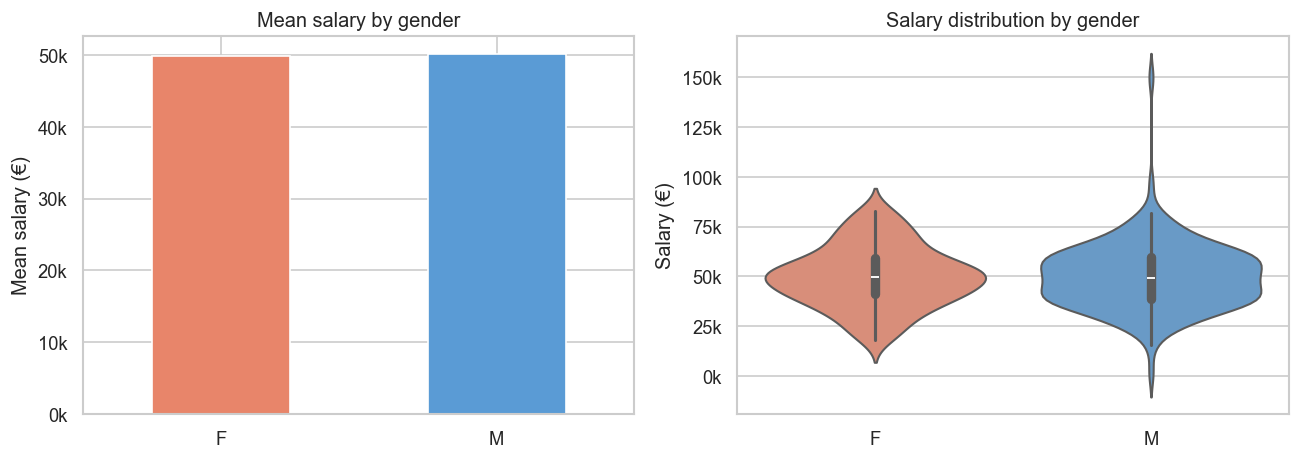

In [10]:
gender_stats = df.groupby("gender")["salary"].agg(["mean", "median", "count"])
gender_stats.columns = ["Mean", "Median", "Headcount"]
display(gender_stats)

mean_m = gender_stats.loc["M", "Mean"]
mean_f = gender_stats.loc["F", "Mean"]
gap_pct = (mean_m - mean_f) / mean_m * 100
print(f"\nGender pay gap (mean): {gap_pct:.1f}%  (M earns {gap_pct:.1f}% more than F on average)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar – mean salary
gender_stats["Mean"].plot(kind="bar", ax=axes[0], color=["#E8856A", "#5A9BD5"], edgecolor="white")
axes[0].set_title("Mean salary by gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean salary (€)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].tick_params(axis="x", rotation=0)

# Violin – full distribution
sns.violinplot(data=df, x="gender", y="salary", palette={"M": "#5A9BD5", "F": "#E8856A"},
               order=["F", "M"], ax=axes[1], inner="box")
axes[1].set_title("Salary distribution by gender")
axes[1].set_xlabel("")
axes[1].set_ylabel("Salary (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.show()

### 4.2 Pay gap by department & grade (adjusted view)

,F,M,gap_pct
department,,,
Finance,"52,227.20","48,862.90",-6.90
HR,"46,340.00","49,710.80",6.80
Marketing,"46,833.30","53,868.20",13.10
Tech,"53,225.00","47,156.10",-12.90


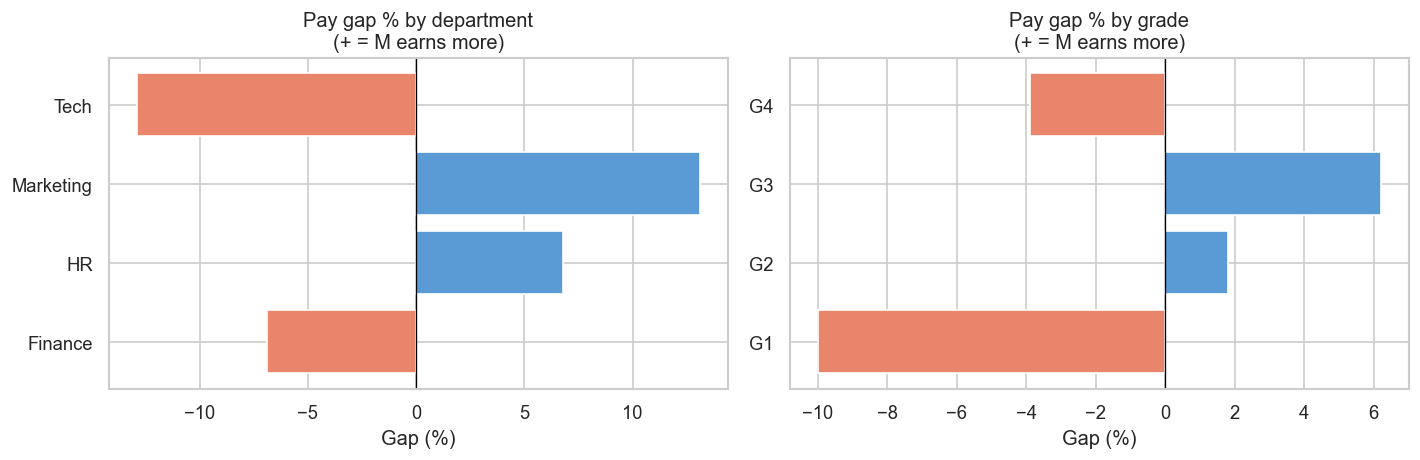

In [11]:
# Pay gap per department
dept_gap = (
    df.groupby(["department", "gender"])["salary"]
    .mean()
    .unstack("gender")
    .assign(gap_pct=lambda x: (x["M"] - x["F"]) / x["M"] * 100)
    .round(1)
)
dept_gap.columns.name = None
display(dept_gap)

# Pay gap per grade
grade_gap = (
    df.groupby(["grade", "gender"])["salary"]
    .mean()
    .unstack("gender")
    .reindex(grade_order)
    .assign(gap_pct=lambda x: (x["M"] - x["F"]) / x["M"] * 100)
    .round(1)
)
grade_gap.columns.name = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Department heatmap-style bars
colors_bar = ["#E8856A" if v < 0 else "#5A9BD5" for v in dept_gap["gap_pct"]]
axes[0].barh(dept_gap.index, dept_gap["gap_pct"], color=colors_bar, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Pay gap % by department\n(+ = M earns more)")
axes[0].set_xlabel("Gap (%)")

colors_bar2 = ["#E8856A" if v < 0 else "#5A9BD5" for v in grade_gap["gap_pct"]]
axes[1].barh(grade_gap.index, grade_gap["gap_pct"], color=colors_bar2, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Pay gap % by grade\n(+ = M earns more)")
axes[1].set_xlabel("Gap (%)")

plt.tight_layout()
plt.show()

## 5. Absenteeism & Compensation

### 5.1 Absences by department & grade

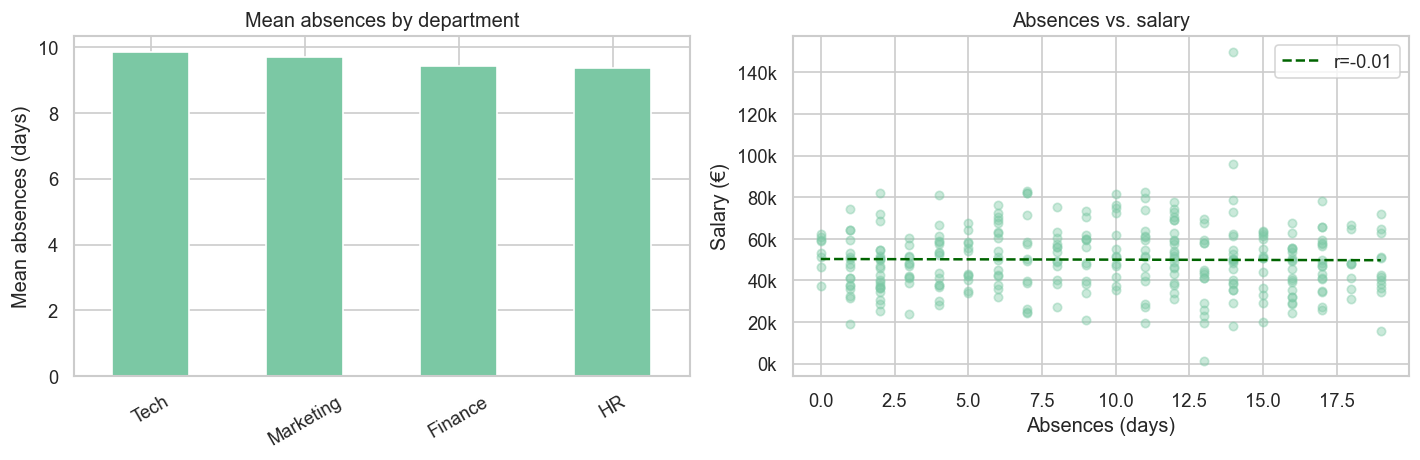

Pearson correlation (absences vs salary): -0.011


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean absences by department
abs_dept = df.groupby("department")["absences"].mean().sort_values(ascending=False)
abs_dept.plot(kind="bar", ax=axes[0], color="#7BC8A4", edgecolor="white")
axes[0].set_title("Mean absences by department")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean absences (days)")
axes[0].tick_params(axis="x", rotation=30)

# Scatter: absences vs salary
corr_abs = df["absences"].corr(df["salary"])
axes[1].scatter(df["absences"], df["salary"], alpha=0.4, s=25, color="#7BC8A4")
m2, b2 = np.polyfit(df["absences"], df["salary"], 1)
x2 = np.linspace(df["absences"].min(), df["absences"].max(), 100)
axes[1].plot(x2, m2 * x2 + b2, color="darkgreen", linestyle="--", label=f"r={corr_abs:.2f}")
axes[1].set_title("Absences vs. salary")
axes[1].set_xlabel("Absences (days)")
axes[1].set_ylabel("Salary (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pearson correlation (absences vs salary): {corr_abs:.3f}")

## 6. Summary & Key Findings

| # | Finding | Category |
|---|---------|----------|
| 1 | Salary outliers detected via IQR — review and validate with HR | Data Quality |
| 2 | Some employees have salaries below their grade floor — possible data entry errors | Data Quality |
| 3 | Tech department shows the highest median salary; HR the lowest | Compensation |
| 4 | Salary progression with grade is not always monotonic — inconsistency in grading | Compensation |
| 5 | Experience shows weak/moderate correlation with salary → grade/department matter more | Compensation |
| 6 | Gender pay gap exists at global level — needs adjustment for grade & department before conclusions | Pay Equity |
| 7 | Pay gap varies significantly across departments — some show reverse gap | Pay Equity |
| 8 | Absences show no strong correlation with salary level | Absenteeism |

> **Next steps:** Verify outliers with the HR team, apply a regression model controlling for grade & experience to isolate the true gender pay gap, and investigate grade-salary floor breaches.